# DS_P673(Clustering)

**Cluster Analysis**


Business Objective: Creating clusters on global development measurement dataset

**Data Set Details:**

The dataset has information about important economic and development metrics related to various countries across the globe.

**Variable Description:**

Birth Rate, Business tax, CO2emissions, Country, Days to start business, Ease of business, energy usage, GDP, healthexp%GDP, healthexp/capita, hours to do tax, infant mortality, internet usage, lending rate, life expectancy female, etc.

**Acceptance Criterion:**

Work on different clustering models, do a comparative analysis and need to deploy the clustering application on streamlit, flask etc.


# Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
import re
import textwrap

In [3]:
plt.style.use('ggplot')

In [4]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
std=StandardScaler()
mm=MinMaxScaler()

In [5]:
from sklearn.preprocessing import OrdinalEncoder
ord=OrdinalEncoder()

In [6]:
from sklearn.decomposition import PCA

In [7]:
from sklearn.cluster import KMeans,DBSCAN,AgglomerativeClustering

In [8]:
from sklearn.mixture import GaussianMixture

In [9]:
from sklearn.metrics import silhouette_score
'''
    Performance Standard
   1      =   Perfect Clustering
 0.7-1    =   Excellent
0.5-0.7   =   Good
0.25-0.5  =   Acceptable
 >0.25    =   Weak
   0      =   Wrong Clustering
'''

'\n    Performance Standard\n   1      =   Perfect Clustering\n 0.7-1    =   Excellent\n0.5-0.7   =   Good\n0.25-0.5  =   Acceptable\n >0.25    =   Weak\n   0      =   Wrong Clustering\n'

In [10]:
!pip install yellowbrick
from yellowbrick.cluster import KElbowVisualizer

In [11]:
from sklearn.neighbors import NearestNeighbors

In [12]:
import pickle

In [13]:
!pip install streamlit
import streamlit as st

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 85.8 MB/s eta 0:00:00


In [14]:
import getpass

In [15]:
!pip install streamlit pyngrok

# Datasets

In [16]:
# Loading the Data
df=pd.read_excel('/content/World_development_mesurement.xlsx')
df.tail()

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
2699,NaN,NaN,NaN,Turks and Caicos Islands,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1,NaN,NaN,NaN,32427,0.911,NaN,NaN
2700,0.013,46.4%,NaN,United States,5.0,4.0,2132446.0,"$16,244,600,000,000",0.179,"$8,895",...,76.0,1.0,1,0.196,0.667,0.136,313873685,0.811,"$200,092,000,000","$126,573,000,000"
2701,0.015,41.9%,NaN,Uruguay,7.0,85.0,NaN,"$50,004,354,667",0.089,"$1,308",...,74.0,1.5,1,0.220,0.639,0.140,3395253,0.948,"$2,222,000,000","$1,028,000,000"
2702,0.020,61.9%,NaN,"Venezuela, RB",144.0,180.0,NaN,"$381,286,223,859",0.046,$593,...,72.0,1.0,1,0.288,0.652,0.060,29954782,0.889,"$904,000,000","$3,202,000,000"
2703,0.011,NaN,NaN,Virgin Islands (U.S.),NaN,NaN,NaN,NaN,NaN,NaN,...,76.0,NaN,1,0.206,0.641,0.152,105275,0.949,NaN,NaN


In [17]:
pd.set_option('display.max_columns',None) # Just to view all Columns
pd.set_option('display.float_format','{:.2f}'.format) # Just to avoid large number with 'e'
pd.set_option('display.max_rows', None)

# Terminology

Birth Rate = Out of 1000 people number of births (of 1000)

Business Tax Rate = Tax on profit charged on buisness (%)

CO2 Emissions = Amount of Co2 released in the atmosphere

Country = Unique country names

Days to Start Business = Duration taken to setup a buisness

Ease of Business = Ranking by the World Bank to judge the buisness Environment

Energy Usage = Energy consumed by a country

GDP = Value of all goods and service produced by the country in a year

Health Exp % GDP = How much of GDP goes in healthcare sector (%)

Health Exp/Capita = Healthcare expense by a single person

Hours to do Tax = Time taken to do the tax compliances

Infant Mortality Rate = Death of infant out of 1000 births (of 1000)

Internet Usage = Percentage of population who have acces to Internet (%)

Lending Interest = Interest Rate charged by banks on loans (%)

Life Expectancy Female = Average Lifespan of female

Life Expectancy Male = Average Lifespan of male

Mobile Phone Usage = Percent of population with access to mobile (%)

Number of Records = Number of entries (USELESS)

Population 0-14 = Percent of population below 14 (%)

Population 15-64 = Percent of population between 15 and 64 (%)

Population 65+ = Percent of population above 65 (%)

Population Total = Total number of people

Population Urban  = Percent of population in urban areas (%)

Tourism Inbound = Amount earned for foreign tourists

Tourism Outbound = amount spent by people in other countries

# Exploratory Data Analysis

In [18]:
# Basic Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              2585 non-null   float64
 1   Business Tax Rate       1423 non-null   object 
 2   CO2 Emissions           2125 non-null   float64
 3   Country                 2704 non-null   object 
 4   Days to Start Business  1718 non-null   float64
 5   Ease of Business        185 non-null    float64
 6   Energy Usage            1785 non-null   float64
 7   GDP                     2494 non-null   object 
 8   Health Exp % GDP        2395 non-null   float64
 9   Health Exp/Capita       2395 non-null   object 
 10  Hours to do Tax         1416 non-null   float64
 11  Infant Mortality Rate   2444 non-null   float64
 12  Internet Usage          2531 non-null   float64
 13  Lending Interest        1880 non-null   float64
 14  Life Expectancy Female  2568 non-null   

In [19]:
print('Number of Unique Values')
print('='*30)
for x in df.columns:
  print(f'{x} = {len(df[x].unique())}')
  print('-'*30)

Number of Unique Values
Birth Rate = 48
------------------------------
Business Tax Rate = 448
------------------------------
CO2 Emissions = 1744
------------------------------
Country = 208
------------------------------
Days to Start Business = 127
------------------------------
Ease of Business = 186
------------------------------
Energy Usage = 1722
------------------------------
GDP = 2495
------------------------------
Health Exp % GDP = 146
------------------------------
Health Exp/Capita = 1070
------------------------------
Hours to do Tax = 281
------------------------------
Infant Mortality Rate = 130
------------------------------
Internet Usage = 12
------------------------------
Lending Interest = 352
------------------------------
Life Expectancy Female = 50
------------------------------
Life Expectancy Male = 48
------------------------------
Mobile Phone Usage = 27
------------------------------
Number of Records = 1
------------------------------
Population 0-14 = 3

In [20]:
len(df['Country'].unique())
# There are a total of 208 Countries in the dataset

208

In [21]:
df['Country'].value_counts().head()
# This Shows that all countries have exactly 13 rows of data

,count
Country,
Algeria,13
Angola,13
Benin,13
Botswana,13
Burkina Faso,13


In [22]:
dff=df.copy()

In [23]:
df=dff.copy()

In [24]:
# converting 10% ==> 0.10
df['Business Tax Rate']=df['Business Tax Rate'].str.replace('%','')
df['Business Tax Rate']=df['Business Tax Rate'].astype('float')
df['Business Tax Rate (%)']=df['Business Tax Rate']/100
df.drop(columns='Business Tax Rate',inplace=True)

# converting large numbers into thousands
df['CO2 Emissions (in Thousands)']=df['CO2 Emissions']/1000
df.drop(columns='CO2 Emissions',inplace=True)

# converting large numbers into thousands
df['Energy Usage (in Thousands)']=df['Energy Usage']/1000
df.drop(columns='Energy Usage',inplace=True)

# converting large numbers into millions
df['GDP']=df['GDP'].str.replace('$','').str.replace(',','')
df['GDP']=df['GDP'].astype('float')
df['GDP (in Millions)']=df['GDP']/1000000
df.drop(columns='GDP',inplace=True)

# removing $ to get number
df['Health Exp/Capita']=df['Health Exp/Capita'].str.replace('$','').str.replace(',','')
df['Health Exp/Capita']=df['Health Exp/Capita'].astype('float')

# Useless column
df.drop(columns='Number of Records',inplace=True)

# converting large numbers into thousands
df['Population Total (in Millions)']=df['Population Total']/1000000
df.drop(columns='Population Total',inplace=True)

# converting large numbers into thousands
df['Tourism Inbound']=df['Tourism Inbound'].str.replace('$','').str.replace(',','')
df['Tourism Inbound']=df['Tourism Inbound'].astype('float')
df['Tourism Inbound (in Millions)']=df['Tourism Inbound']/1000000
df.drop(columns='Tourism Inbound',inplace=True)

# converting large numbers into thousands
df['Tourism Outbound']=df['Tourism Outbound'].str.replace('$','').str.replace(',','')
df['Tourism Outbound']=df['Tourism Outbound'].astype('float')
df['Tourism Outbound (in Millions)']=df['Tourism Outbound']/1000000
df.drop(columns='Tourism Outbound',inplace=True)

df['Years']=df.groupby('Country')['Country'].rank(method='first')

df.head()

,Birth Rate,Country,Days to Start Business,Ease of Business,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Urban,Business Tax Rate (%),CO2 Emissions (in Thousands),Energy Usage (in Thousands),GDP (in Millions),Population Total (in Millions),Tourism Inbound (in Millions),Tourism Outbound (in Millions),Years
0,0.02,Algeria,NaN,NaN,0.04,60.00,NaN,0.03,0.00,0.10,71.00,67.00,0.00,0.34,0.62,0.04,0.60,NaN,87.93,27.00,54790.06,31.72,102.00,193.00,1.00
1,0.05,Angola,NaN,NaN,0.03,22.00,NaN,0.13,0.00,1.03,47.00,44.00,0.00,0.48,0.50,0.03,0.32,NaN,9.54,7.50,9129.59,13.92,34.00,146.00,1.00
2,0.04,Benin,NaN,NaN,0.04,15.00,NaN,0.09,0.00,NaN,57.00,53.00,0.00,0.45,0.52,0.03,0.38,NaN,1.62,1.98,2359.12,6.95,77.00,50.00,1.00
3,0.03,Botswana,NaN,NaN,0.05,152.00,NaN,0.05,0.00,0.15,52.00,49.00,0.10,0.38,0.59,0.03,0.53,NaN,4.28,1.84,5788.31,1.76,227.00,209.00,1.00
4,0.05,Burkina Faso,NaN,NaN,0.05,12.00,NaN,0.10,0.00,NaN,52.00,49.00,0.00,0.47,0.51,0.03,0.18,NaN,1.04,NaN,2610.96,11.61,23.00,30.00,1.00


In [25]:
def country_report(country):
  '''
  Just enter the name of the country and you will get a complete report of all various factors to compare. If data is not available the chart will mention it.
  '''
  x=df[df['Country']==country]
  plt.figure(figsize=(12,20))
  plt.suptitle(f'Report of {country}\n ',size=20,color='red')

  plt.subplot(5,2,1)
  x['urban']=x['Population Total (in Millions)']*x['Population Urban']
  if x[['urban','Population Total (in Millions)']].isnull().sum().sum()>10:
    plt.text(7,0.5,'Data is not Available',size=15,ha='center',va='center')
  else:
    plt.plot(x['Years'],x['Population Total (in Millions)'],lw=5,color='blue')
    plt.fill_between(x['Years'],x['Population Total (in Millions)'],color='blue',alpha=0.2)
    plt.plot(x['Years'],x['urban'],label='Urban',lw=5,color='green')
    plt.fill_between(x['Years'],x['urban'],color='green',alpha=0.2)
  plt.title('Population Distribution',size=20,color='red')
  plt.ylabel('in Millions',color='blue')
  plt.xlabel('Years',color='blue')
  plt.xlim(0,14)
  plt.legend()

  plt.subplot(5,2,2)
  if x[['Population 0-14','Population 15-64','Population 65+']].isnull().sum().sum()>10:
    plt.text(7,0.5,'Data is not Available',size=15,ha='center',va='center')
  else:
    plt.plot(x['Years'],x['Population 0-14'],label='0-14',lw=5,color='yellow')
    plt.fill_between(x['Years'],x['Population 0-14'],color='yellow',alpha=0.2)
    plt.plot(x['Years'],x['Population 15-64'],label='15-64',lw=5,color='green')
    plt.fill_between(x['Years'],x['Population 15-64'],color='green',alpha=0.2)
    plt.plot(x['Years'],x['Population 65+'],label='65+',lw=5,color='grey')
    plt.fill_between(x['Years'],x['Population 65+'],color='grey',alpha=0.2)
  plt.title('Demographic',size=20,color='red')
  plt.ylabel('Percent',color='blue')
  plt.xlabel('Years',color='blue')
  plt.xlim(0,14)
  plt.legend()

  plt.subplot(5,2,3)
  if x[['Birth Rate','Infant Mortality Rate']].isnull().sum().sum()>10:
    plt.text(7,0.5,'Data is not Available',size=15,ha='center',va='center')
  else:
    plt.plot(x['Years'],x['Birth Rate'],label='Birth Rate',lw=5,color='yellow')
    plt.fill_between(x['Years'],x['Birth Rate'],alpha=0.4,color='yellow')
    plt.plot(x['Years'],x['Infant Mortality Rate'],label='infant Mortality',lw=5,color='red')
  plt.title('Child Mortality',size=20,color='red')
  plt.xlim(0,14)
  plt.ylabel('Per 1000',color='blue')
  plt.xlabel('Years',color='blue')
  plt.legend()

  plt.subplot(5,2,4)
  if x[['Life Expectancy Female','Life Expectancy Male']].isnull().sum().sum()>10:
    plt.text(7,0.5,'Data is not Available',size=15,ha='center',va='center')
  else:
    plt.plot(x['Years'],x['Life Expectancy Female'],lw=5,label=f'Female',color='pink')
    plt.plot(x['Years'],x['Life Expectancy Male'],lw=5,label=f'Male',color='blue')
  plt.title('Life Expectancy',size=20,color='red')
  plt.ylabel('Life Expectency',color='blue')
  plt.xlim(0,14)
  plt.xlabel('Years',color='blue')
  plt.legend()

  plt.subplot(5,2,5)
  x['health']=x['GDP (in Millions)']*x['Health Exp % GDP']
  if x[['GDP (in Millions)','health']].isnull().sum().sum()>10:
    plt.text(7,0.5,'Data is not Available',size=15,ha='center',va='center')
  else:
    plt.plot(x['Years'],x['GDP (in Millions)'],lw=5,color='blue')
    plt.fill_between(x['Years'],x['GDP (in Millions)'],color='blue',alpha=0.2)
    plt.plot(x['Years'],x['health'],label='Health',lw=5,color='green')
    plt.fill_between(x['Years'],x['health'],color='green',alpha=0.2)
  plt.title('Health Expense by GDP',size=20,color='red')
  plt.xlim(0,14)
  plt.ylabel('in Millions',color='blue')
  plt.xlabel('Years',color='blue')
  plt.legend()

  plt.subplot(5,2,6)
  if x[['Tourism Inbound (in Millions)','Tourism Outbound (in Millions)']].isnull().sum().sum()>10:
    plt.text(7,0.5,'Data is not Available',size=15,ha='center',va='center')
  else:
    plt.plot(x['Years'],x['Tourism Inbound (in Millions)'],label='Inflow',lw=5,color='blue')
    plt.plot(x['Years'],x['Tourism Outbound (in Millions)'],label='Outflow',lw=5,color='red')
    plt.fill_between(x['Years'],x['Tourism Inbound (in Millions)'],x['Tourism Outbound (in Millions)'],alpha=0.4,color='grey')
  plt.title('Toursim',size=20,color='red')
  plt.ylabel('in Millions',color='blue')
  plt.xlim(0,14)
  plt.xlabel('Years',color='blue')
  plt.legend()

  plt.subplot(5,2,7)
  x['hours to start buisness']=x['Days to Start Business']*24
  if x[['hours to start buisness','Hours to do Tax']].isnull().sum().sum()>10:
    plt.text(7,0.5,'Data is not Available',size=15,ha='center',va='center')
  else:
    plt.plot(x['Years'],x['hours to start buisness'],lw=5,color='blue',label='To Start Buisness')
    plt.fill_between(x['Years'],x['hours to start buisness'],color='blue',alpha=0.2)
    plt.plot(x['Years'],x['Hours to do Tax'],label='To do Tax',lw=5,color='green')
    plt.fill_between(x['Years'],x['Hours to do Tax'],color='green',alpha=0.2)
  plt.title(f'Buisness Metrics',size=20,color='red')
  plt.text(8,x['hours to start buisness'].max()-(x['hours to start buisness'].max()*1/4),f'Ease of Doing Buisness Rank\n{x['Ease of Business'].iloc[-1]}',size=10,color='red')
  plt.ylabel('Hours',color='blue')
  plt.xlim(0,14)
  plt.xlabel('Years',color='blue')
  plt.legend()

  plt.subplot(5,2,8)
  if x[['Lending Interest','Business Tax Rate (%)']].isnull().sum().sum()>10:
    plt.text(7,0.5,'Data is not Available',size=15,ha='center',va='center')
  else:
    plt.plot(x['Years'],x['Lending Interest'],label='Interest Rates',lw=5)
    plt.fill_between(x['Years'],x['Lending Interest'],alpha=0.2)
    plt.plot(x['Years'],x['Business Tax Rate (%)'],label='Tax Rates',lw=5,color='green')
    plt.fill_between(x['Years'],x['Business Tax Rate (%)'],alpha=0.5,color='green')
  plt.title('Intrest and Taxes',size=20,color='red')
  plt.ylabel('Percent',color='blue')
  plt.xlim(0,14)
  plt.xlabel('Years',color='blue')
  plt.legend()

  plt.subplot(5,2,9)
  if x[['Mobile Phone Usage','Internet Usage']].isnull().sum().sum()>10:
    plt.text(7,0.5,'Data is not Available',size=15,ha='center',va='center')
  else:
    plt.plot(x['Years'],x['Mobile Phone Usage'],label='Mobile Usage',lw=5)
    plt.fill_between(x['Years'],x['Mobile Phone Usage'],alpha=0.2)
    plt.plot(x['Years'],x['Internet Usage'],label='Internet Usage',lw=5,color='green')
    plt.fill_between(x['Years'],x['Internet Usage'],alpha=0.5,color='green')
  plt.title('Digital FootPrint',size=20,color='red')
  plt.ylabel('Usage (in %)',color='blue')
  plt.xlabel('Years',color='blue')
  plt.xlim(0,14)
  plt.legend()

  plt.subplot(5,2,10)
  if x[['CO2 Emissions (in Thousands)','Energy Usage (in Thousands)']].isnull().sum().sum()>10:
    plt.text(7,0.5,'Data is not Available',size=15,ha='center',va='center')
  else:
    plt.plot(x['Years'],x['CO2 Emissions (in Thousands)'],label='Emissions',lw=5,color='grey')
    plt.fill_between(x['Years'],x['CO2 Emissions (in Thousands)'],color='grey',alpha=0.25)
    plt.plot(x['Years'],x['Energy Usage (in Thousands)'],label='Energy Consumption',lw=5,color='red')
  plt.title('Environmental FootPrint',size=20,color='red')
  plt.xlim(0,14)
  plt.ylabel('Emission / Usage (in Thousands)',color='blue')
  plt.xlabel('Years',color='blue')
  plt.legend()

  plt.tight_layout()

In [26]:
c=df['Country'].unique().tolist()
t=', '.join(c)
print(textwrap.fill(t,width=100))
# Choose a country to Test

Algeria, Angola, Benin, Botswana, Burkina Faso, Burundi, Cameroon, Central African Republic, Chad,
Comoros, Congo, Dem. Rep., Congo, Rep., Cote d'Ivoire, Djibouti, Egypt, Arab Rep., Equatorial
Guinea, Eritrea, Ethiopia, Gabon, Gambia, The, Ghana, Guinea, Guinea-Bissau, Kenya, Lesotho,
Liberia, Libya, Madagascar, Malawi, Mali, Mauritania, Mauritius, Morocco, Mozambique, Namibia,
Niger, Nigeria, Rwanda, Sao Tome and Principe, Senegal, Seychelles, Sierra Leone, Somalia, South
Africa, South Sudan, Sudan, Swaziland, Tanzania, Togo, Tunisia, Uganda, Zambia, Zimbabwe,
Afghanistan, Armenia, Azerbaijan, Bangladesh, Bhutan, Brunei Darussalam, Cambodia, China, Georgia,
Hong Kong SAR, China, India, Indonesia, Japan, Kazakhstan, Korea, Dem. Rep., Korea, Rep., Kyrgyz
Republic, Lao PDR, Macao SAR, China, Malaysia, Maldives, Mongolia, Myanmar, Nepal, Pakistan,
Philippines, Singapore, Sri Lanka, Tajikistan, Thailand, Timor-Leste, Turkmenistan, Uzbekistan,
Vietnam, Albania, Andorra, Austria, Belarus, Be

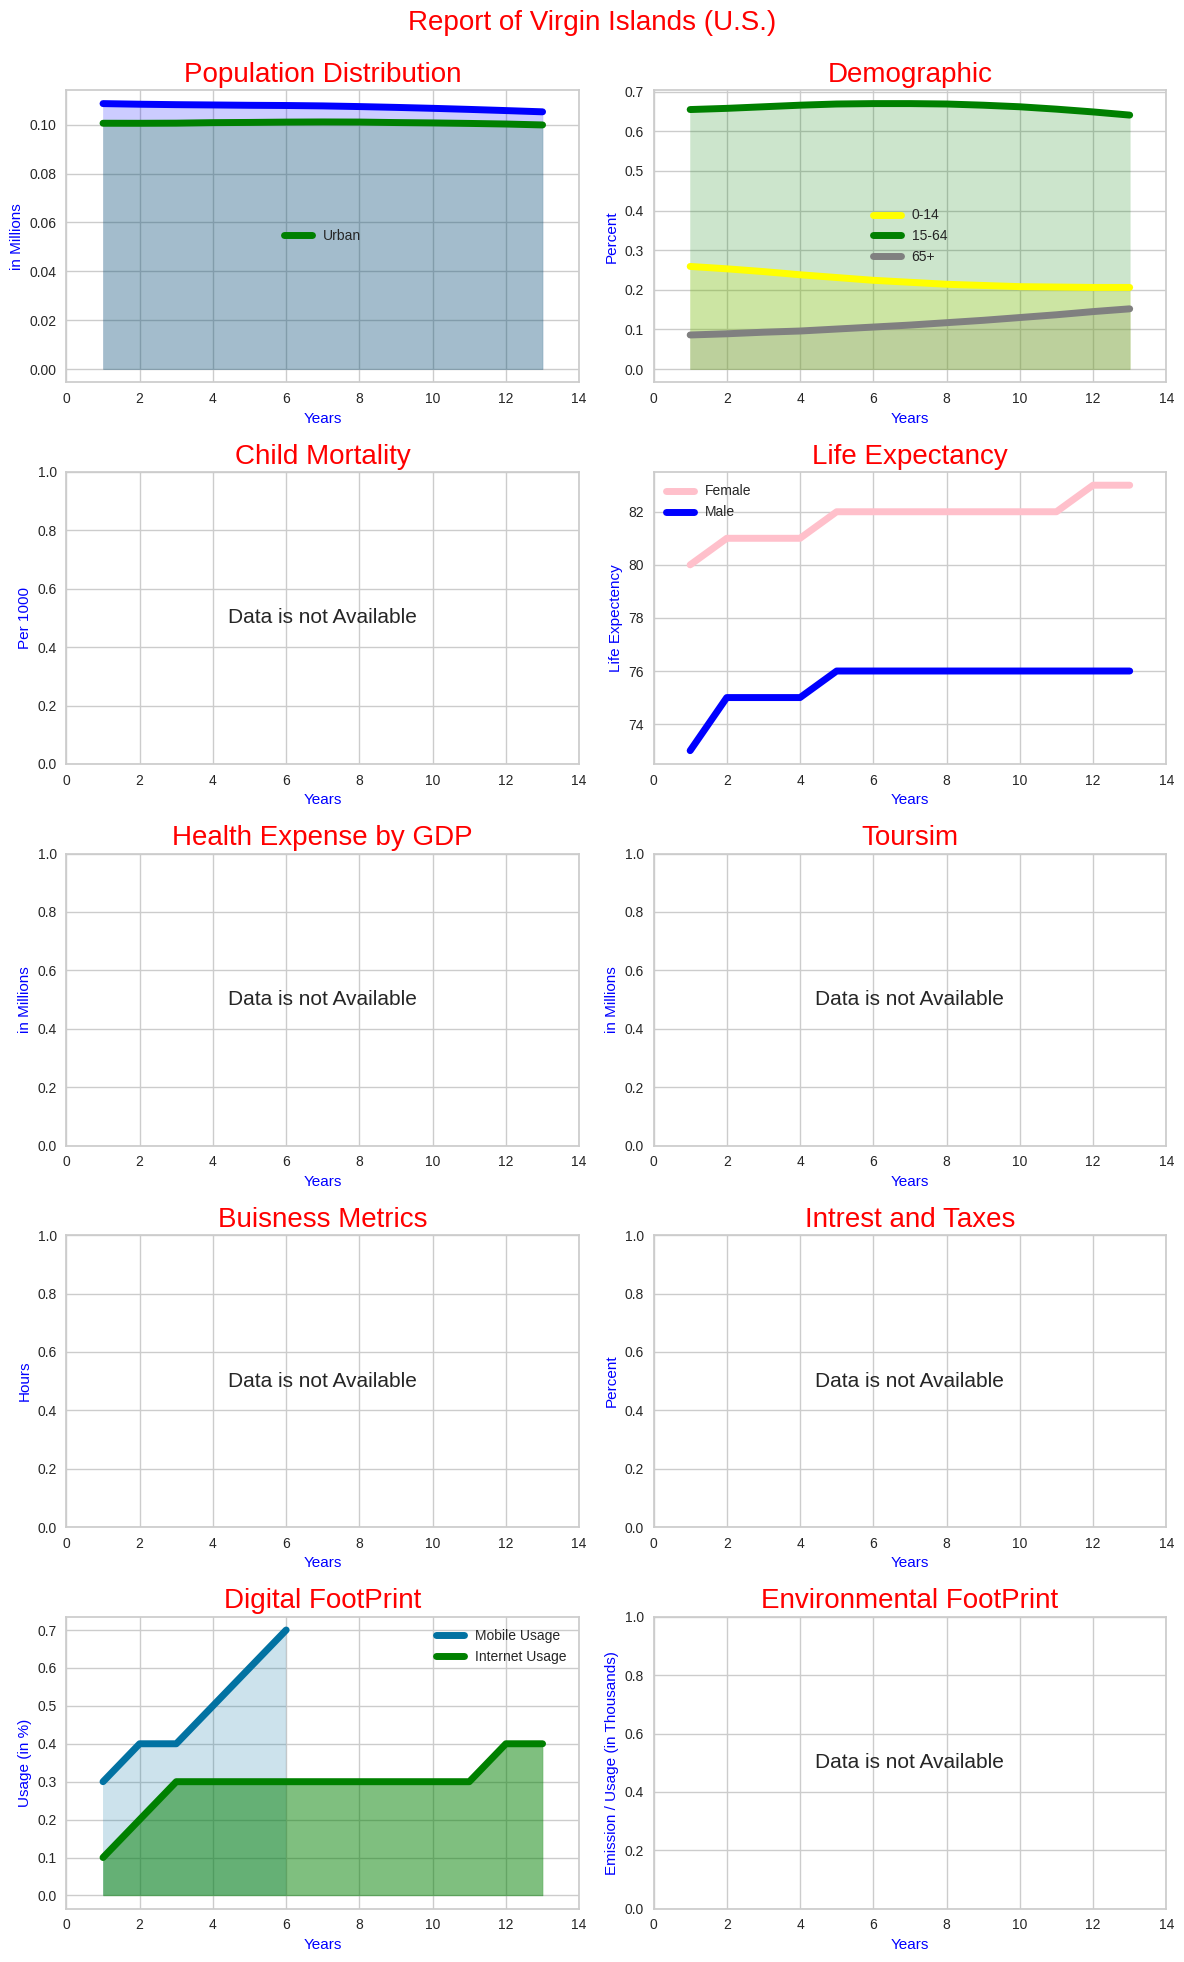

In [27]:
country_report('Virgin Islands (U.S.)')

In [28]:
# Checking Missing Values
df.isnull().sum()

,0
Birth Rate,119
Country,0
Days to Start Business,986
Ease of Business,2519
Health Exp % GDP,309
Health Exp/Capita,309
Hours to do Tax,1288
Infant Mortality Rate,260
Internet Usage,173
Lending Interest,824


In [29]:
# Dropping column as more than 90% data is missing
df.drop(columns=['Years','Ease of Business'],inplace=True)
df=df.groupby('Country').median().reset_index()

In [30]:
# Filling missing values of each country with the median of each country for all columns
num=df.drop(columns=('Country')).columns
df[num]=df[num].fillna(df[num].median())
df.head()

,Country,Birth Rate,Days to Start Business,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Urban,Business Tax Rate (%),CO2 Emissions (in Thousands),Energy Usage (in Thousands),GDP (in Millions),Population Total (in Millions),Tourism Inbound (in Millions),Tourism Outbound (in Millions)
0,Afghanistan,0.04,9.00,0.09,30.00,275.00,0.08,0.00,0.15,59.00,56.00,0.20,0.49,0.49,0.02,0.23,0.36,1.02,9.13,8450.72,25.63,116.00,80.00
1,Albania,0.01,22.50,0.06,168.00,364.00,0.02,0.10,0.13,80.00,73.00,0.60,0.26,0.65,0.09,0.48,0.41,4.06,2.06,9132.56,2.97,1057.00,989.00
2,Algeria,0.02,25.00,0.04,106.00,451.00,0.03,0.10,0.08,72.00,68.00,0.60,0.28,0.67,0.04,0.65,0.73,103.96,33.50,117026.66,34.51,300.00,504.00
3,American Samoa,0.02,26.00,0.06,210.00,230.00,0.02,0.10,0.11,75.00,69.00,0.00,0.30,0.64,0.05,0.88,0.41,7.71,9.13,16338.51,0.06,645.00,418.50
4,Andorra,0.01,26.00,0.06,2631.00,230.00,0.00,0.60,0.11,75.00,69.00,0.80,0.30,0.64,0.05,0.90,0.41,0.54,9.13,2322.16,0.08,645.00,418.50


(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22]),
 [Text(1, 0, 'Birth Rate'),
  Text(2, 0, 'Days to Start Business'),
  Text(3, 0, 'Health Exp % GDP'),
  Text(4, 0, 'Health Exp/Capita'),
  Text(5, 0, 'Hours to do Tax'),
  Text(6, 0, 'Infant Mortality Rate'),
  Text(7, 0, 'Internet Usage'),
  Text(8, 0, 'Lending Interest'),
  Text(9, 0, 'Life Expectancy Female'),
  Text(10, 0, 'Life Expectancy Male'),
  Text(11, 0, 'Mobile Phone Usage'),
  Text(12, 0, 'Population 0-14'),
  Text(13, 0, 'Population 15-64'),
  Text(14, 0, 'Population 65+'),
  Text(15, 0, 'Population Urban'),
  Text(16, 0, 'Business Tax Rate (%)'),
  Text(17, 0, 'CO2 Emissions (in Thousands)'),
  Text(18, 0, 'Energy Usage (in Thousands)'),
  Text(19, 0, 'GDP (in Millions)'),
  Text(20, 0, 'Population Total (in Millions)'),
  Text(21, 0, 'Tourism Inbound (in Millions)'),
  Text(22, 0, 'Tourism Outbound (in Millions)')])

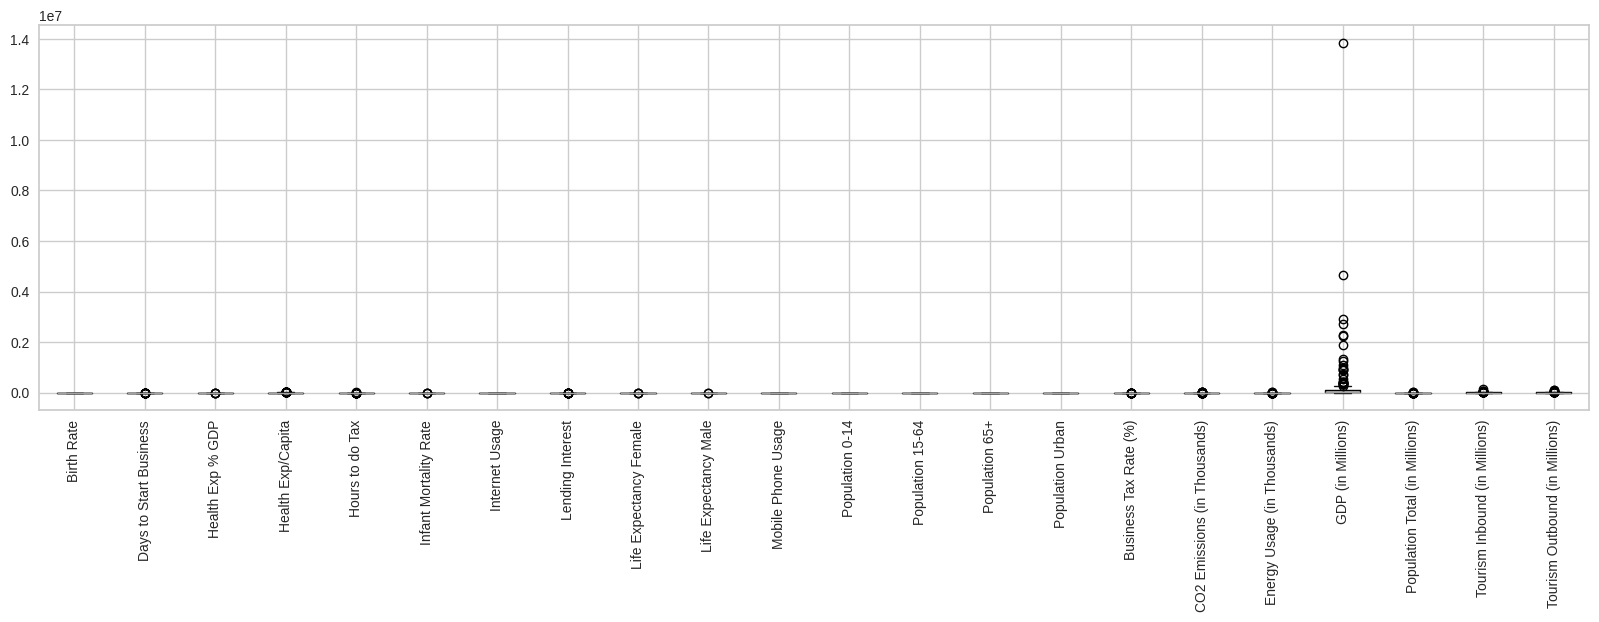

In [31]:
# Checking for outliers
plt.figure(figsize=(20,5))
df[num].boxplot()
plt.xticks(rotation=90)

In [32]:
# Checking which columns have huge outlier skewness
for x in df[num]:
  a=df[x].max()/df[x].median()
  print(f'{x} = {a}')

Birth Rate = 2.6153846153846154
Days to Start Business = 26.692307692307693
Health Exp % GDP = 2.8852459016393444
Health Exp/Capita = 33.857142857142854
Hours to do Tax = 11.304347826086957
Infant Mortality Rate = 6.25
Internet Usage = 9.0
Lending Interest = 8.535087719298245
Life Expectancy Female = 1.1466666666666667
Life Expectancy Male = 1.1594202898550725
Mobile Phone Usage = 3.4
Population 0-14 = 1.6515912897822447
Population 15-64 = 1.2634032634032635
Population 65+ = 3.8130841121495327
Population Urban = 1.7889087656529514
Business Tax Rate (%) = 7.133089133089134
CO2 Emissions (in Thousands) = 751.1698235599376
Energy Usage (in Thousands) = 247.62098231396814
GDP (in Millions) = 848.1739894155278
Population Total (in Millions) = 230.56333272366592
Tourism Inbound (in Millions) = 206.8108527131783
Tourism Outbound (in Millions) = 252.03345280764637


In [33]:
def out_cap(df,c):
  q1=df[c].quantile(0.25)
  q3=df[c].quantile(0.75)
  iqr=q3-q1
  le=q1-1.5*iqr
  ue=q3+1.5*iqr
  df[c]=df[c].apply(lambda x:ue if x>ue else le if x<le else x)

# Capping outlier for all column which had values more than 20
caps=['CO2 Emissions (in Thousands)','Energy Usage (in Thousands)','GDP (in Millions)','Population Total (in Millions)','Tourism Inbound (in Millions)',
'Tourism Outbound (in Millions)']
for x in df[caps]:
  out_cap(df,x)

In [34]:
# Scaling the data
df_s=pd.DataFrame(std.fit_transform(df[num]),columns=df[num].columns)

In [35]:
df_s.head()

,Birth Rate,Days to Start Business,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Urban,Business Tax Rate (%),CO2 Emissions (in Thousands),Energy Usage (in Thousands),GDP (in Millions),Population Total (in Millions),Tourism Inbound (in Millions),Tourism Outbound (in Millions)
0,1.93,-0.52,1.17,-0.52,-0.05,1.81,-0.94,0.22,-1.18,-1.16,-0.87,1.88,-2.10,-1.09,-1.35,-0.30,-0.72,-0.43,-0.62,0.73,-0.72,-0.75
1,-0.75,-0.28,-0.10,-0.42,0.31,-0.51,-0.52,-0.02,0.82,0.70,0.13,-0.43,0.42,0.36,-0.35,-0.17,-0.66,-0.79,-0.61,-0.64,-0.35,-0.09
2,-0.04,-0.23,-1.11,-0.46,0.67,-0.12,-0.52,-0.59,0.06,0.15,0.13,-0.19,0.71,-0.56,0.34,0.63,1.48,0.80,0.54,1.27,-0.65,-0.45
3,-0.17,-0.22,-0.10,-0.39,-0.24,-0.40,-0.52,-0.20,0.34,0.26,-1.36,-0.03,0.26,-0.39,1.30,-0.18,-0.58,-0.43,-0.53,-0.81,-0.51,-0.51
4,-1.06,-0.22,-0.05,1.41,-0.24,-1.01,1.55,-0.20,0.34,0.26,0.62,-0.03,0.26,-0.39,1.37,-0.18,-0.73,-0.43,-0.68,-0.81,-0.51,-0.51


In [36]:
# Converting the 22 column into 2 for clustering
pca=PCA(n_components=2)
df_new=pd.DataFrame(pca.fit_transform(df_s))
df_new.head()

,0,1
0,4.34,1.21
1,-0.25,-1.66
2,-0.39,1.35
3,0.53,-1.37
4,-1.20,-2.24


In [37]:
data=df_new.copy()

# Model Building

## Kmeans

In [38]:
df_new=data.copy()

In [39]:
# Basic Model with 2 clusters
km=KMeans(n_clusters=2,random_state=100)
cluster=km.fit(df_new)

In [40]:
silhouette_score(df_new,cluster.labels_)
# Silhouete Score is acceptable but we could perform better

np.float64(0.44491312298267427)

In [41]:
# Adding labels to the data
df_new['cluster']=cluster.labels_
df_new.head()

,0,1,cluster
0,4.34,1.21,1
1,-0.25,-1.66,0
2,-0.39,1.35,0
3,0.53,-1.37,0
4,-1.20,-2.24,0


In [42]:
# Number of row in each cluster
df_new['cluster'].value_counts()

,count
cluster,
0,127
1,81


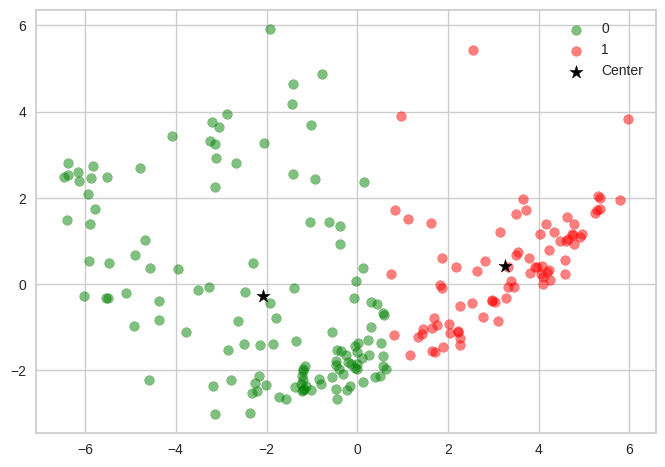

In [43]:
# Visualizing cluster
df_0=df_new[df_new['cluster']==0]
df_1=df_new[df_new['cluster']==1]

plt.scatter(df_0[0],df_0[1],label='0',color='green',alpha=0.5)
plt.scatter(df_1[0],df_1[1],label='1',color='red',alpha=0.5)
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='black',marker='*',s=100,label='Center')

plt.legend()

### Best Kmeans

1   2855.549919796041
2   1423.3654535583084
3   722.0741827330544
4   523.049064295859
5   384.25162475186403
6   337.8277592485317
7   270.7567753143757
8   239.5429624949401
9   193.7164908178883
10   197.86136475980476
11   156.38797947071228
12   146.02152245141798
13   138.19651462024595
14   119.02054896144124
15   102.126554371121
16   101.56261758903727
17   95.58369445773391
18   82.9627234379243
19   85.69986204568208


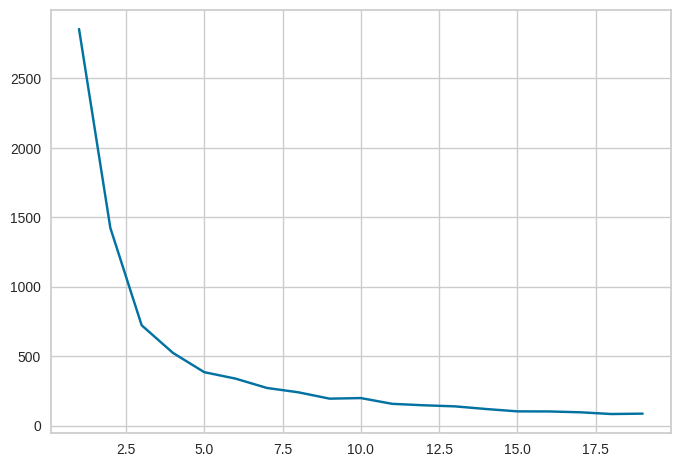

In [44]:
# Elbow Method to find best k value
sse=[]
for x in range(1,20):
  km=KMeans(n_clusters=x)
  km.fit(df_new[[0,1]])
  sse.append(km.inertia_)
  print(x,' ',km.inertia_)

plt.plot(range(1,20),sse)

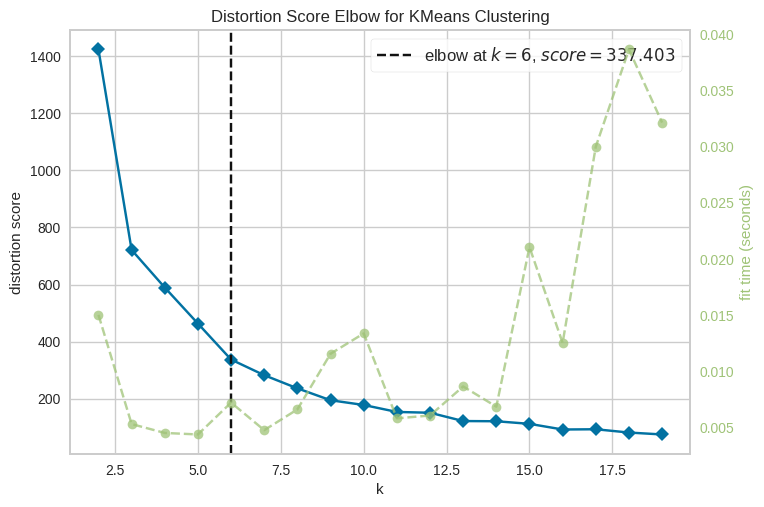

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [45]:
# Yellowbrick and KElboviusalizer
km=KMeans()
vis=KElbowVisualizer(km,k=(2,20),metrics='silhoutte')
vis.fit(data)
vis.show()

In [46]:
df_new=data.copy()

0.456221375712097


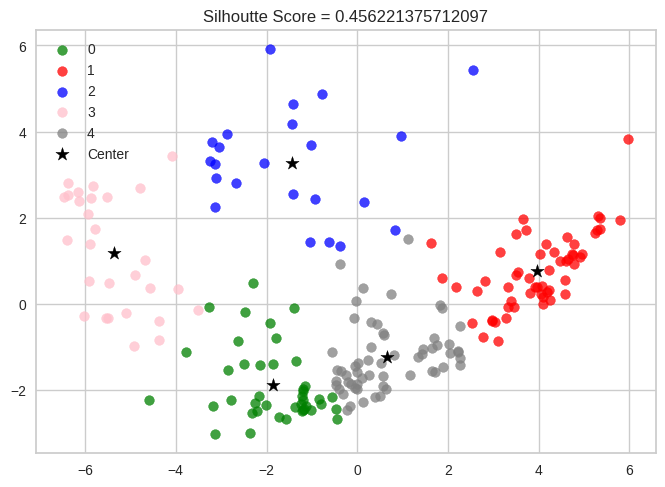

In [47]:
# As we can see both method confirm best k is 5
km=KMeans(n_clusters=5,random_state=100)
cluster=km.fit(df_new)
sil_kmean=silhouette_score(df_new,cluster.labels_)
print(sil_kmean)
df_new['cluster']=cluster.labels_
labels=cluster.labels_

df_0=df_new[df_new['cluster']==0]
df_1=df_new[df_new['cluster']==1]
df_2=df_new[df_new['cluster']==2]
df_3=df_new[df_new['cluster']==3]
df_4=df_new[df_new['cluster']==4]
# df_5=df_new[df_new['cluster']==5]

plt.scatter(df_0[0],df_0[1],label='0',color='green',alpha=0.75)
plt.scatter(df_1[0],df_1[1],label='1',color='red',alpha=0.75)
plt.scatter(df_2[0],df_2[1],label='2',color='blue',alpha=0.75)
plt.scatter(df_3[0],df_3[1],label='3',color='pink',alpha=0.75)
plt.scatter(df_4[0],df_4[1],label='4',color='grey',alpha=0.75)
# plt.scatter(df_5[0],df_5[1],label='5',color='yellow',alpha=0.75)
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='black',marker='*',s=100,label='Center')
plt.title(f'Silhoutte Score = {sil_kmean}')

plt.legend()

In [48]:
# Unscaling the data
df_o=pd.DataFrame(std.inverse_transform(df_s),columns=df_s.columns)
df_o['cluster']=labels
df_o.head()

,Birth Rate,Days to Start Business,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Urban,Business Tax Rate (%),CO2 Emissions (in Thousands),Energy Usage (in Thousands),GDP (in Millions),Population Total (in Millions),Tourism Inbound (in Millions),Tourism Outbound (in Millions),cluster
0,0.04,9.00,0.09,30.00,275.00,0.08,0.00,0.15,59.00,56.00,0.20,0.49,0.49,0.02,0.23,0.36,1.02,9.13,8450.72,25.63,116.00,80.00,1
1,0.01,22.50,0.06,168.00,364.00,0.02,0.10,0.13,80.00,73.00,0.60,0.26,0.65,0.09,0.48,0.41,4.06,2.06,9132.56,2.97,1057.00,989.00,4
2,0.02,25.00,0.04,106.00,451.00,0.03,0.10,0.08,72.00,68.00,0.60,0.28,0.67,0.04,0.65,0.73,103.96,33.50,117026.66,34.51,300.00,504.00,2
3,0.02,26.00,0.06,210.00,230.00,0.02,0.10,0.11,75.00,69.00,0.00,0.30,0.64,0.05,0.88,0.41,7.71,9.13,16338.51,0.06,645.00,418.50,4
4,0.01,26.00,0.06,2631.00,230.00,0.00,0.60,0.11,75.00,69.00,0.80,0.30,0.64,0.05,0.90,0.41,0.53,9.13,2322.16,0.08,645.00,418.50,0


In [49]:
# Checking the information of each cluster
df_o.groupby('cluster').mean().T

cluster,0,1,2,3,4
Birth Rate,0.01,0.04,0.02,0.01,0.02
Days to Start Business,25.90,56.02,39.70,14.89,40.35
Health Exp % GDP,0.07,0.06,0.05,0.09,0.06
Health Exp/Capita,1108.90,59.32,226.30,3018.68,213.54
Hours to do Tax,226.04,313.93,515.87,206.46,255.43
Infant Mortality Rate,0.01,0.07,0.03,0.01,0.02
Internet Usage,0.42,0.02,0.14,0.61,0.14
Lending Interest,0.10,0.18,0.13,0.07,0.14
Life Expectancy Female,79.07,56.84,72.13,81.86,74.49
Life Expectancy Male,73.31,54.55,66.52,76.04,68.81


In [50]:
df_o['country']=df['Country']
# 3>0>2>4>1

In [51]:
cl=[3,0,2,4,1]
for x in cl:
  print(f'Cluster {x} Countries')
  c=df_o[df_o['cluster']==x]['country'].tolist()
  t=' / '.join(c)
  print(textwrap.fill(t,width=100))
  print('='*100)

Cluster 3 Countries
Australia / Austria / Belgium / Canada / Czech Republic / Denmark / Finland / France / Germany /
Greece / Hong Kong SAR, China / Hungary / Ireland / Italy / Japan / Korea, Rep. / Netherlands /
Norway / Poland / Portugal / Russian Federation / Singapore / Spain / Sweden / Switzerland / United
Arab Emirates / United Kingdom / United States
Cluster 0 Countries
Andorra / Aruba / Bahamas, The / Bahrain / Barbados / Belarus / Bermuda / Bosnia and Herzegovina /
Brunei Darussalam / Bulgaria / Cayman Islands / Chile / Croatia / Cuba / Curacao / Cyprus / Dominica
/ Estonia / Faeroe Islands / Iceland / Israel / Kuwait / Latvia / Lebanon / Liechtenstein /
Lithuania / Luxembourg / Macao SAR, China / Macedonia, FYR / Malta / Monaco / Montenegro / New
Zealand / Puerto Rico / Qatar / Romania / San Marino / Serbia / Slovak Republic / Slovenia / Uruguay
/ Virgin Islands (U.S.)
Cluster 2 Countries
Algeria / Argentina / Brazil / China / Colombia / Egypt, Arab Rep. / India / Indonesia /

*   In terms of Development parameters we can say that cluster 3 comprises of all the Developed countires as is evident with the high GDP and the low infant mortality rate. Not only that but the have a higher urban population as well as higher energy Consumption and co2 Emissions. They also have a high digital penetration and are more easy in term of buisness environment. They even have a higher percent of GDP spent on health which shows the high life expectency. Along with this they have a thriving tourism industry as well.

*   They are followed by cluster 0 the countries that are growing at a fast rate. They have a friendly buisness environment along with a sizable population in urban areas. They also are well connected digitally as they have a higher acces to internet. There health infrastructure is also good chunk of there GDP as can be seen with a higher life expectency. There energy consumption may be low but it doesnot impact the other factors. A small nudge could push these countries upwards.

*  They are followed by cluster 2 which does have a high GDP and economic factors but is not doing well in the social factor. They have a higher infant mortaliuty rate, the urban population is low, internet penetration is also low. These may be indicating that these coiuntries have high disparity among its people where a small majority enjoys higher benefits compared to the masses. These nation require inclusive growth to move forward.

*  They are followed by cluster 4 these countries are underdeveloped countries. These countries need to move towards better healtcare infrastructure as it would boost productivity. The also need to digitze better in order to get better delivery of goods and services which can be acheived as a sizable population is in the working age. They may have to improve there buisess environment to attract better economic oppurtunities. These countries have a long road ahead to boost the performance.

*   And finally the underdeveloped countires. They not only have a low GDP but they have a severe health crisis. Majority of the population is under 14 and they average lifespan is less that 60 along with a very high infant mortality rate indicating that these countries have a crisis in the health side. The energy consumption or the internet usage is low as well, that mean they are not utilising there potential. These nation need to do a lot of work in order to boost the development parameters of there nation.






## Agglomerative Clustering

In [52]:
df_new=data.copy()

In [53]:
ag=AgglomerativeClustering(n_clusters=2)
cluster=ag.fit(df_new)

In [54]:
silhouette_score(df_new,cluster.labels_)

np.float64(0.4324219084777731)

In [55]:
df_new['cluster']=cluster.labels_
df_new.head()

,0,1,cluster
0,4.34,1.21,1
1,-0.25,-1.66,0
2,-0.39,1.35,0
3,0.53,-1.37,0
4,-1.20,-2.24,0


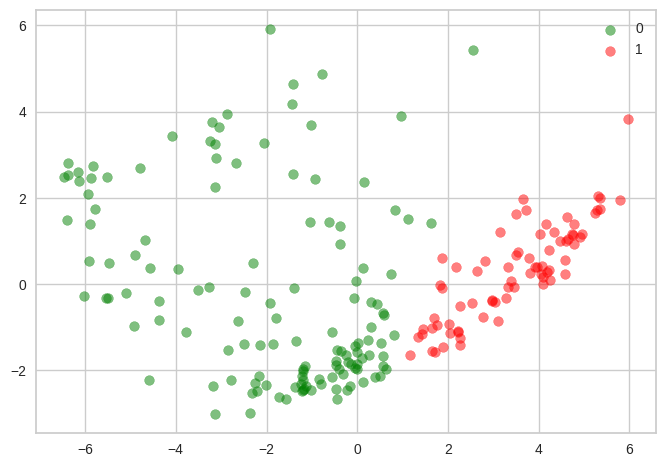

In [56]:
df_0=df_new[df_new['cluster']==0]
df_1=df_new[df_new['cluster']==1]

plt.scatter(df_0[0],df_0[1],label='0',color='green',alpha=0.5)
plt.scatter(df_1[0],df_1[1],label='1',color='red',alpha=0.5)

plt.legend()

### Best Model

In [57]:
df_new=data.copy()

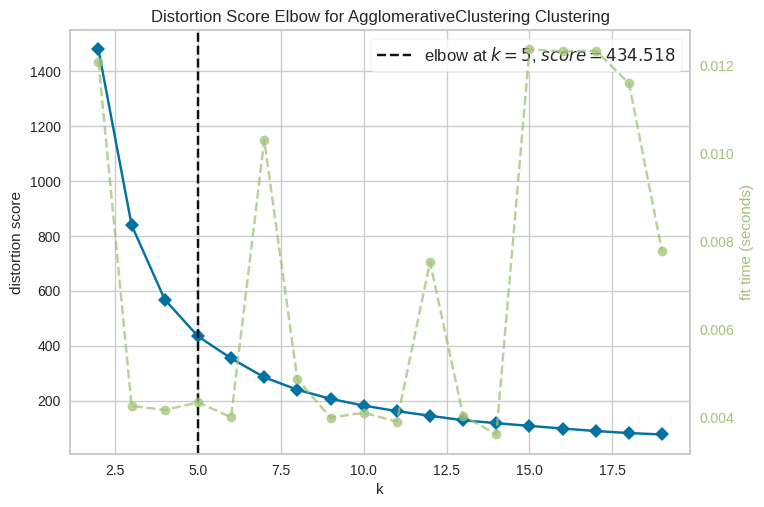

<Axes: title={'center': 'Distortion Score Elbow for AgglomerativeClustering Clustering'}, xlabel='k', ylabel='distortion score'>

In [58]:
ag=AgglomerativeClustering()
vis=KElbowVisualizer(ag,k=(2,20),metrics='silhoutte')
vis.fit(data)
vis.show()

0.44495985852249176


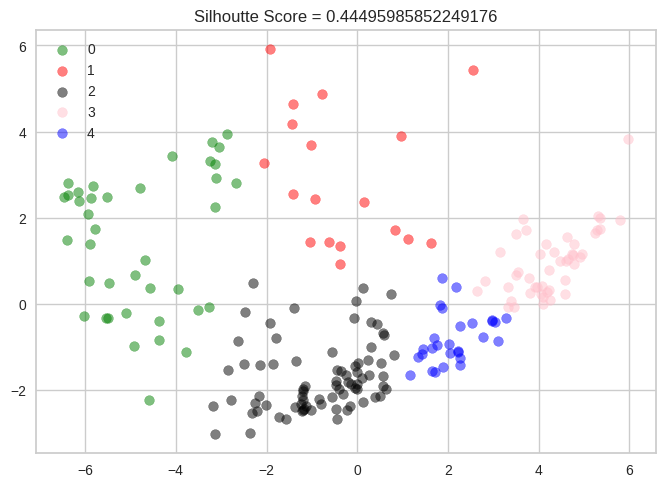

In [59]:
df_new=data.copy()

ag=AgglomerativeClustering(n_clusters=5)
cluster=ag.fit(df_new)
label=cluster.labels_
sil_agglo=silhouette_score(df_new,cluster.labels_)
print(sil_agglo)
df_new['cluster']=cluster.labels_

df_0=df_new[df_new['cluster']==0]
df_1=df_new[df_new['cluster']==1]
df_2=df_new[df_new['cluster']==2]
df_3=df_new[df_new['cluster']==3]
df_4=df_new[df_new['cluster']==4]

plt.scatter(df_0[0],df_0[1],label='0',color='green',alpha=0.5)
plt.scatter(df_1[0],df_1[1],label='1',color='red',alpha=0.5)
plt.scatter(df_2[0],df_2[1],label='2',color='black',alpha=0.5)
plt.scatter(df_3[0],df_3[1],label='3',color='pink',alpha=0.5)
plt.scatter(df_4[0],df_4[1],label='4',color='blue',alpha=0.5)

plt.title(f'Silhoutte Score = {sil_agglo}')
plt.legend()

In [60]:
df_o=pd.DataFrame(std.inverse_transform(df_s),columns=df_s.columns)
df_o['cluster']=label
df_o.head()

,Birth Rate,Days to Start Business,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Urban,Business Tax Rate (%),CO2 Emissions (in Thousands),Energy Usage (in Thousands),GDP (in Millions),Population Total (in Millions),Tourism Inbound (in Millions),Tourism Outbound (in Millions),cluster
0,0.04,9.00,0.09,30.00,275.00,0.08,0.00,0.15,59.00,56.00,0.20,0.49,0.49,0.02,0.23,0.36,1.02,9.13,8450.72,25.63,116.00,80.00,3
1,0.01,22.50,0.06,168.00,364.00,0.02,0.10,0.13,80.00,73.00,0.60,0.26,0.65,0.09,0.48,0.41,4.06,2.06,9132.56,2.97,1057.00,989.00,2
2,0.02,25.00,0.04,106.00,451.00,0.03,0.10,0.08,72.00,68.00,0.60,0.28,0.67,0.04,0.65,0.73,103.96,33.50,117026.66,34.51,300.00,504.00,1
3,0.02,26.00,0.06,210.00,230.00,0.02,0.10,0.11,75.00,69.00,0.00,0.30,0.64,0.05,0.88,0.41,7.71,9.13,16338.51,0.06,645.00,418.50,2
4,0.01,26.00,0.06,2631.00,230.00,0.00,0.60,0.11,75.00,69.00,0.80,0.30,0.64,0.05,0.90,0.41,0.53,9.13,2322.16,0.08,645.00,418.50,2


In [61]:
df_o.groupby('cluster').mean().T

cluster,0,1,2,3,4
Birth Rate,0.01,0.02,0.02,0.04,0.03
Days to Start Business,17.26,44.53,26.56,53.34,70.09
Health Exp % GDP,0.08,0.05,0.06,0.06,0.06
Health Exp/Capita,2515.21,148.22,588.55,48.87,139.14
Hours to do Tax,235.03,550.72,254.22,310.48,244.79
Infant Mortality Rate,0.01,0.04,0.01,0.07,0.04
Internet Usage,0.52,0.11,0.30,0.01,0.06
Lending Interest,0.07,0.15,0.11,0.19,0.16
Life Expectancy Female,80.74,70.00,77.51,55.43,68.68
Life Expectancy Male,75.00,64.94,71.66,53.35,63.82


In [62]:
df_o['country']=df['Country']
# 0>2>1>3>4

In [63]:
cl=[0,2,1,3,4]
for x in cl:
  print(f'Cluster {x} Countries')
  c=df_o[df_o['cluster']==x]['country'].tolist()
  t=' / '.join(c)
  print(textwrap.fill(t,width=100))
  print('='*100)

Cluster 0 Countries
Argentina / Australia / Austria / Belgium / Canada / China / Czech Republic / Denmark / Finland /
France / Germany / Greece / Hong Kong SAR, China / Hungary / Ireland / Israel / Italy / Japan /
Korea, Rep. / Luxembourg / Malaysia / Mexico / Netherlands / New Zealand / Norway / Poland /
Portugal / Russian Federation / Saudi Arabia / Singapore / Spain / Sweden / Switzerland / Thailand /
Turkey / Ukraine / United Arab Emirates / United Kingdom / United States
Cluster 2 Countries
Albania / American Samoa / Andorra / Antigua and Barbuda / Armenia / Aruba / Azerbaijan / Bahamas,
The / Bahrain / Barbados / Belarus / Bermuda / Bosnia and Herzegovina / Brunei Darussalam / Bulgaria
/ Cayman Islands / Chile / Costa Rica / Croatia / Cuba / Curacao / Cyprus / Dominica / Dominican
Republic / Ecuador / El Salvador / Estonia / Faeroe Islands / French Polynesia / Georgia / Greenland
/ Grenada / Guam / Iceland / Isle of Man / Jamaica / Jordan / Korea, Dem. Rep. / Kosovo / Kuwait /
La

## DBSCAN

In [64]:
df_new=data.copy()

In [65]:
nn=NearestNeighbors(n_neighbors=5)
nn.fit(df_new)
dist,ind=nn.kneighbors(df_new)

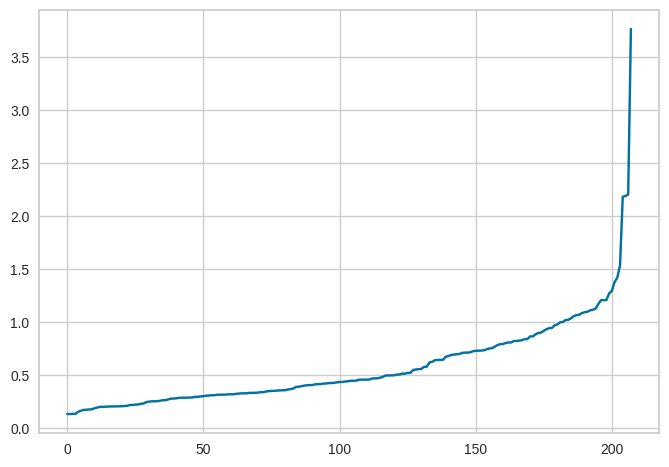

In [66]:
dist=np.sort(dist,axis=0)
dist=dist[:,-1]
plt.plot(dist)

In [67]:
eps=np.arange(0.5,2.25,0.05)
min_node=range(2,21)

In [68]:
output=[]
for i in eps:
  for j in min_node:
    label=DBSCAN(eps=i,min_samples=j).fit(df_new).labels_
    if len(np.unique(label))>=2:
      score=silhouette_score(df_new,label)
      output.append([i,j,score])
eps,min_node,score=sorted(output,key=lambda x:x[2],reverse=True)[0]
print(eps,min_node,score)

1.550000000000001 18 0.4547087214842818


In [69]:
db=DBSCAN(eps=1.55,min_samples=18)
db.fit(df_new)
label=db.labels_
sil_db=silhouette_score(df_new,db.labels_)

In [70]:
np.unique(label)

array([-1,  0])

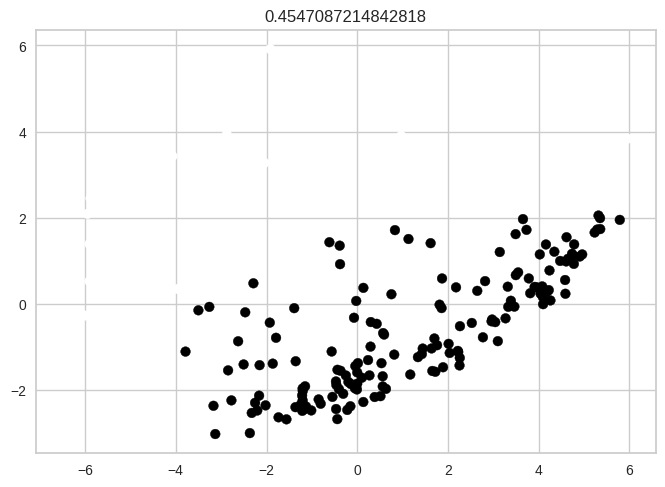

In [71]:
plt.scatter(df_new[0],df_new[1],c=label)
plt.title(f'{sil_db}')
sil_db=silhouette_score(df_new,db.labels_)

## Gausian Mixture Model

In [72]:
df_new=data.copy()

In [73]:
gmm=GaussianMixture(n_components=2,random_state=100)
label=gmm.fit_predict(df_new)
print(silhouette_score(df_new,label))

0.38575550069308157


In [74]:
df_new['cluster']=label
df_new.head()

,0,1,cluster
0,4.34,1.21,1
1,-0.25,-1.66,1
2,-0.39,1.35,0
3,0.53,-1.37,1
4,-1.20,-2.24,1


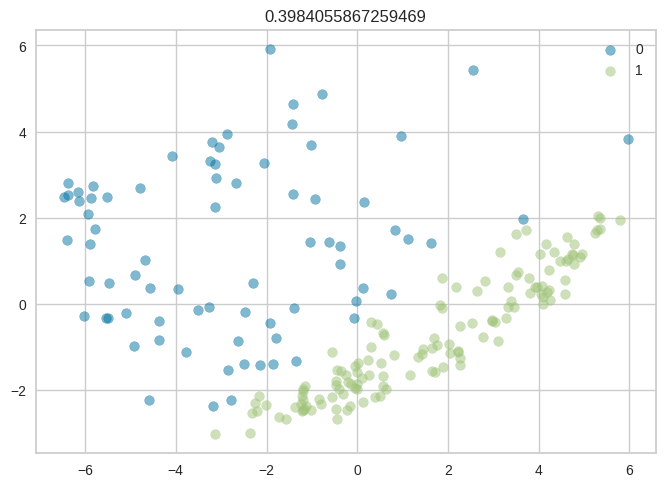

In [75]:
df_0=df_new[df_new['cluster']==0]
df_1=df_new[df_new['cluster']==1]

plt.scatter(df_0[0],df_0[1],label='0',alpha=0.5)
plt.scatter(df_1[0],df_1[1],label='1',alpha=0.5)
plt.title(silhouette_score(df_new,label))

plt.legend()

### Best Model

In [76]:
df_new=data.copy()

2   0.38575550069308157
3   0.42063933932308706
4   0.4207158298046558
5   0.3642521327006146
6   0.3538743066690448
7   0.30533587198620843
8   0.4404766804270452
9   0.3707442317265573
10   0.34538937425550653
11   0.3274385277517329
12   0.3556644288102709
13   0.34754249932201997
14   0.3458050404177712
15   0.2911687095027648
16   0.29867850601005885
17   0.3202954223072233
18   0.31933835202084965
19   0.30735576889004074
20   0.29539188117705406


Text(0.5, 1.0, 'Best k => 8')

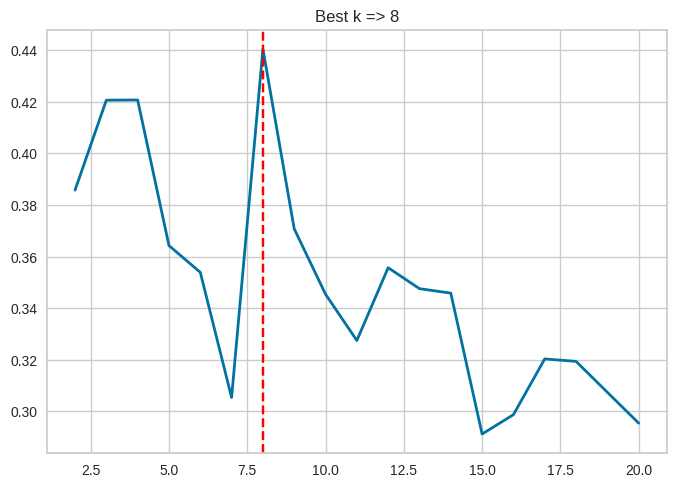

In [77]:
k=range(2,21)
b=[]
for x in k:
  gmm=GaussianMixture(n_components=x,random_state=100)
  label=gmm.fit_predict(df_new)
  print(x,' ',silhouette_score(df_new,label))
  b.append(silhouette_score(df_new,label))
plt.plot(range(2,21),b,lw=2)
plt.axvline(b.index(max(b))+2,linestyle='--',color='red')
plt.title(f'Best k => {b.index(max(b))+2}')

In [78]:
gmm=GaussianMixture(n_components=8,random_state=100)
label=gmm.fit_predict(df_new)
sil_gaus=silhouette_score(df_new,label)
print(sil_gaus)

0.4404766804270452


In [79]:
df_new['cluster']=label
df_new.head()

,0,1,cluster
0,4.34,1.21,1
1,-0.25,-1.66,0
2,-0.39,1.35,3
3,0.53,-1.37,0
4,-1.20,-2.24,0


In [80]:
np.unique(label)

array([0, 1, 2, 3, 4, 5, 6, 7])

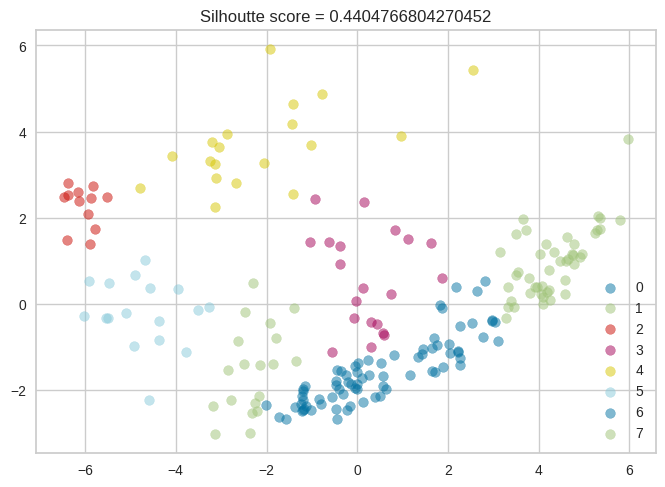

In [81]:
df_0=df_new[df_new['cluster']==0]
df_1=df_new[df_new['cluster']==1]
df_2=df_new[df_new['cluster']==2]
df_3=df_new[df_new['cluster']==3]
df_4=df_new[df_new['cluster']==4]
df_5=df_new[df_new['cluster']==5]
df_6=df_new[df_new['cluster']==6]
df_7=df_new[df_new['cluster']==7]

plt.scatter(df_0[0],df_0[1],label='0',alpha=0.5)
plt.scatter(df_1[0],df_1[1],label='1',alpha=0.5)
plt.scatter(df_2[0],df_2[1],label='2',alpha=0.5)
plt.scatter(df_3[0],df_3[1],label='3',alpha=0.5)
plt.scatter(df_4[0],df_4[1],label='4',alpha=0.5)
plt.scatter(df_5[0],df_5[1],label='5',alpha=0.5)
plt.scatter(df_6[0],df_6[1],label='6',alpha=0.5)
plt.scatter(df_7[0],df_7[1],label='7',alpha=0.5)

plt.title(f'Silhoutte score = {sil_gaus}')
plt.legend()

In [82]:
df_o=pd.DataFrame(std.inverse_transform(df_s),columns=df_s.columns)
df_o['cluster']=label
df_o.head()

,Birth Rate,Days to Start Business,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Urban,Business Tax Rate (%),CO2 Emissions (in Thousands),Energy Usage (in Thousands),GDP (in Millions),Population Total (in Millions),Tourism Inbound (in Millions),Tourism Outbound (in Millions),cluster
0,0.04,9.00,0.09,30.00,275.00,0.08,0.00,0.15,59.00,56.00,0.20,0.49,0.49,0.02,0.23,0.36,1.02,9.13,8450.72,25.63,116.00,80.00,1
1,0.01,22.50,0.06,168.00,364.00,0.02,0.10,0.13,80.00,73.00,0.60,0.26,0.65,0.09,0.48,0.41,4.06,2.06,9132.56,2.97,1057.00,989.00,0
2,0.02,25.00,0.04,106.00,451.00,0.03,0.10,0.08,72.00,68.00,0.60,0.28,0.67,0.04,0.65,0.73,103.96,33.50,117026.66,34.51,300.00,504.00,3
3,0.02,26.00,0.06,210.00,230.00,0.02,0.10,0.11,75.00,69.00,0.00,0.30,0.64,0.05,0.88,0.41,7.71,9.13,16338.51,0.06,645.00,418.50,0
4,0.01,26.00,0.06,2631.00,230.00,0.00,0.60,0.11,75.00,69.00,0.80,0.30,0.64,0.05,0.90,0.41,0.53,9.13,2322.16,0.08,645.00,418.50,0


In [83]:
df_o.groupby('cluster').mean().T

cluster,0,1,2,3,4,5,6,7
Birth Rate,0.02,0.04,0.01,0.02,0.02,0.01,0.03,0.01
Days to Start Business,27.08,56.72,13.33,34.05,41.55,14.56,64.65,22.76
Health Exp % GDP,0.06,0.06,0.10,0.05,0.05,0.08,0.06,0.07
Health Exp/Capita,547.12,50.18,3565.92,129.15,286.58,3038.88,138.44,891.47
Hours to do Tax,228.01,313.53,192.83,365.40,539.55,184.56,249.15,251.08
Infant Mortality Rate,0.02,0.07,0.00,0.03,0.03,0.01,0.04,0.01
Internet Usage,0.30,0.02,0.65,0.09,0.17,0.61,0.05,0.38
Lending Interest,0.12,0.19,0.06,0.13,0.14,0.07,0.15,0.10
Life Expectancy Female,77.27,55.36,82.92,73.60,72.11,81.76,68.30,79.05
Life Expectancy Male,71.41,53.22,77.42,67.95,66.58,76.65,63.63,72.89


In [84]:
df_o['country']=df['Country']
# 2>5>4>7>3>0>6>1

In [85]:
cl=[2,5,4,7,3,0,6,1]
for x in cl:
  print(f'Cluster {x} Countries')
  c=df_o[df_o['cluster']==x]['country'].tolist()
  t=' / '.join(c)
  print(textwrap.fill(t,width=100))
  print('='*100)

Cluster 2 Countries
Australia / Belgium / Canada / France / Germany / Italy / Japan / Korea, Rep. / Netherlands / Spain
/ United Kingdom / United States
Cluster 5 Countries
Austria / Czech Republic / Denmark / Finland / Greece / Hong Kong SAR, China / Hungary / Ireland /
Israel / Luxembourg / New Zealand / Norway / Portugal / Singapore / Sweden / Switzerland / United
Arab Emirates
Cluster 4 Countries
Argentina / Brazil / China / Egypt, Arab Rep. / India / Indonesia / Iran, Islamic Rep. / Malaysia /
Mexico / Nigeria / Pakistan / Poland / Russian Federation / Saudi Arabia / South Africa / Thailand /
Turkey / Ukraine / Venezuela, RB
Cluster 7 Countries
Belarus / Bulgaria / Chile / Croatia / Cuba / Cyprus / Estonia / Iceland / Kuwait / Lebanon /
Lithuania / Macao SAR, China / Malta / Puerto Rico / Qatar / Romania / Serbia / Slovak Republic /
Slovenia
Cluster 3 Countries
Algeria / Azerbaijan / Bangladesh / Colombia / Dominican Republic / Ecuador / Iraq / Jordan /
Kazakhstan / Korea, Dem. Re

# Comparison

In [86]:
print(f'KMeans score = {sil_kmean}')
print(f'Agglomerative score = {sil_agglo}')
print(f'DBSCAN score = {sil_db}')
print(f'Gaussian score = {sil_gaus}')

KMeans score = 0.456221375712097
Agglomerative score = 0.44495985852249176
DBSCAN score = 0.4547087214842818
Gaussian score = 0.4404766804270452


In [87]:
file='km.pkl'
pickle.dump(km,open(file,'wb'))

scale='scaler.pkl'
pickle.dump(std,open(scale,'wb'))

pc='pca.pkl'
pickle.dump(pca,open(pc,'wb'))

# Deployment

In [88]:
ngrok_key=getpass.getpass('ENter ngrok key = ')

ENter ngrok key = ··········


In [89]:
# 

In [184]:
%%writefile deploy.py
import streamlit as st
import pickle
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA

model=pickle.load(open('km.pkl','rb'))
scale=pickle.load(open('scaler.pkl','rb'))
pca=pickle.load(open('pca.pkl','rb'))
df=pd.read_excel('/content/World_development_mesurement.xlsx')

df['Business Tax Rate']=df['Business Tax Rate'].str.replace('%','')
df['Business Tax Rate']=df['Business Tax Rate'].astype('float')
df['Business Tax Rate (%)']=df['Business Tax Rate']/100
df.drop(columns='Business Tax Rate',inplace=True)

df['CO2 Emissions (in Thousands)']=df['CO2 Emissions']/1000
df.drop(columns='CO2 Emissions',inplace=True)

df['Energy Usage (in Thousands)']=df['Energy Usage']/1000
df.drop(columns='Energy Usage',inplace=True)

df['GDP']=df['GDP'].str.replace('$','').str.replace(',','')
df['GDP']=df['GDP'].astype('float')
df['GDP (in Millions)']=df['GDP']/1000000
df.drop(columns='GDP',inplace=True)

df['Health Exp/Capita']=df['Health Exp/Capita'].str.replace('$','').str.replace(',','')
df['Health Exp/Capita']=df['Health Exp/Capita'].astype('float')

df.drop(columns='Number of Records',inplace=True)

df['Population Total (in Millions)']=df['Population Total']/1000000
df.drop(columns='Population Total',inplace=True)

df['Tourism Inbound']=df['Tourism Inbound'].str.replace('$','').str.replace(',','')
df['Tourism Inbound']=df['Tourism Inbound'].astype('float')
df['Tourism Inbound (in Millions)']=df['Tourism Inbound']/1000000
df.drop(columns='Tourism Inbound',inplace=True)

df['Tourism Outbound']=df['Tourism Outbound'].str.replace('$','').str.replace(',','')
df['Tourism Outbound']=df['Tourism Outbound'].astype('float')
df['Tourism Outbound (in Millions)']=df['Tourism Outbound']/1000000
df.drop(columns='Tourism Outbound',inplace=True)

df['Years']=df.groupby('Country')['Country'].rank(method='first')

def country_report(country):
  '''
  Just enter the name of the country and you will get a complete report of all various factors to compare. If data is not available the chart will mention it.
  '''
  x=df[df['Country']==country]
  fig=plt.figure(figsize=(12,20))
  plt.suptitle(f'Report of {country}\n ',size=20,color='red')

  plt.subplot(5,2,1)
  x['urban']=x['Population Total (in Millions)']*x['Population Urban']
  if x[['urban','Population Total (in Millions)']].isnull().sum().sum()>10:
    plt.text(7,0.5,'Data is not Available',size=15,ha='center',va='center')
  else:
    plt.plot(x['Years'],x['Population Total (in Millions)'],lw=5,color='blue')
    plt.fill_between(x['Years'],x['Population Total (in Millions)'],color='blue',alpha=0.2)
    plt.plot(x['Years'],x['urban'],label='Urban',lw=5,color='green')
    plt.fill_between(x['Years'],x['urban'],color='green',alpha=0.2)
  plt.title('Population Distribution',size=20,color='red')
  plt.ylabel('in Millions',color='blue')
  plt.xlabel('Years',color='blue')
  plt.xlim(0,14)
  plt.legend()

  plt.subplot(5,2,2)
  if x[['Population 0-14','Population 15-64','Population 65+']].isnull().sum().sum()>10:
    plt.text(7,0.5,'Data is not Available',size=15,ha='center',va='center')
  else:
    plt.plot(x['Years'],x['Population 0-14'],label='0-14',lw=5,color='yellow')
    plt.fill_between(x['Years'],x['Population 0-14'],color='yellow',alpha=0.2)
    plt.plot(x['Years'],x['Population 15-64'],label='15-64',lw=5,color='green')
    plt.fill_between(x['Years'],x['Population 15-64'],color='green',alpha=0.2)
    plt.plot(x['Years'],x['Population 65+'],label='65+',lw=5,color='grey')
    plt.fill_between(x['Years'],x['Population 65+'],color='grey',alpha=0.2)
  plt.title('Demographic',size=20,color='red')
  plt.ylabel('Percent',color='blue')
  plt.xlabel('Years',color='blue')
  plt.xlim(0,14)
  plt.legend()

  plt.subplot(5,2,3)
  if x[['Birth Rate','Infant Mortality Rate']].isnull().sum().sum()>10:
    plt.text(7,0.5,'Data is not Available',size=15,ha='center',va='center')
  else:
    plt.plot(x['Years'],x['Birth Rate'],label='Birth Rate',lw=5,color='yellow')
    plt.fill_between(x['Years'],x['Birth Rate'],alpha=0.4,color='yellow')
    plt.plot(x['Years'],x['Infant Mortality Rate'],label='infant Mortality',lw=5,color='red')
  plt.title('Child Mortality',size=20,color='red')
  plt.xlim(0,14)
  plt.ylabel('Per 1000',color='blue')
  plt.xlabel('Years',color='blue')
  plt.legend()

  plt.subplot(5,2,4)
  if x[['Life Expectancy Female','Life Expectancy Male']].isnull().sum().sum()>10:
    plt.text(7,0.5,'Data is not Available',size=15,ha='center',va='center')
  else:
    plt.plot(x['Years'],x['Life Expectancy Female'],lw=5,label=f'Female',color='pink')
    plt.plot(x['Years'],x['Life Expectancy Male'],lw=5,label=f'Male',color='blue')
  plt.title('Life Expectancy',size=20,color='red')
  plt.ylabel('Life Expectency',color='blue')
  plt.xlim(0,14)
  plt.xlabel('Years',color='blue')
  plt.legend()

  plt.subplot(5,2,5)
  x['health']=x['GDP (in Millions)']*x['Health Exp % GDP']
  if x[['GDP (in Millions)','health']].isnull().sum().sum()>10:
    plt.text(7,0.5,'Data is not Available',size=15,ha='center',va='center')
  else:
    plt.plot(x['Years'],x['GDP (in Millions)'],lw=5,color='blue')
    plt.fill_between(x['Years'],x['GDP (in Millions)'],color='blue',alpha=0.2)
    plt.plot(x['Years'],x['health'],label='Health',lw=5,color='green')
    plt.fill_between(x['Years'],x['health'],color='green',alpha=0.2)
  plt.title('Health Expense by GDP',size=20,color='red')
  plt.xlim(0,14)
  plt.ylabel('in Millions',color='blue')
  plt.xlabel('Years',color='blue')
  plt.legend()

  plt.subplot(5,2,6)
  if x[['Tourism Inbound (in Millions)','Tourism Outbound (in Millions)']].isnull().sum().sum()>10:
    plt.text(7,0.5,'Data is not Available',size=15,ha='center',va='center')
  else:
    plt.plot(x['Years'],x['Tourism Inbound (in Millions)'],label='Inflow',lw=5,color='blue')
    plt.plot(x['Years'],x['Tourism Outbound (in Millions)'],label='Outflow',lw=5,color='red')
    plt.fill_between(x['Years'],x['Tourism Inbound (in Millions)'],x['Tourism Outbound (in Millions)'],alpha=0.4,color='grey')
  plt.title('Toursim',size=20,color='red')
  plt.ylabel('in Millions',color='blue')
  plt.xlim(0,14)
  plt.xlabel('Years',color='blue')
  plt.legend()

  plt.subplot(5,2,7)
  x['hours to start buisness']=x['Days to Start Business']*24
  if x[['hours to start buisness','Hours to do Tax']].isnull().sum().sum()>10:
    plt.text(7,0.5,'Data is not Available',size=15,ha='center',va='center')
  else:
    plt.plot(x['Years'],x['hours to start buisness'],lw=5,color='blue',label='To Start Buisness')
    plt.fill_between(x['Years'],x['hours to start buisness'],color='blue',alpha=0.2)
    plt.plot(x['Years'],x['Hours to do Tax'],label='To do Tax',lw=5,color='green')
    plt.fill_between(x['Years'],x['Hours to do Tax'],color='green',alpha=0.2)
  plt.title(f'Buisness Metrics',size=20,color='red')
  plt.text(8,x['hours to start buisness'].max()-(x['hours to start buisness'].max()*1/4),f'Ease of Doing Buisness Rank\n{x['Ease of Business'].iloc[-1]}',size=10,color='red')
  plt.ylabel('Hours',color='blue')
  plt.xlim(0,14)
  plt.xlabel('Years',color='blue')
  plt.legend()

  plt.subplot(5,2,8)
  if x[['Lending Interest','Business Tax Rate (%)']].isnull().sum().sum()>10:
    plt.text(7,0.5,'Data is not Available',size=15,ha='center',va='center')
  else:
    plt.plot(x['Years'],x['Lending Interest'],label='Interest Rates',lw=5)
    plt.fill_between(x['Years'],x['Lending Interest'],alpha=0.2)
    plt.plot(x['Years'],x['Business Tax Rate (%)'],label='Tax Rates',lw=5,color='green')
    plt.fill_between(x['Years'],x['Business Tax Rate (%)'],alpha=0.5,color='green')
  plt.title('Intrest and Taxes',size=20,color='red')
  plt.ylabel('Percent',color='blue')
  plt.xlim(0,14)
  plt.xlabel('Years',color='blue')
  plt.legend()

  plt.subplot(5,2,9)
  if x[['Mobile Phone Usage','Internet Usage']].isnull().sum().sum()>10:
    plt.text(7,0.5,'Data is not Available',size=15,ha='center',va='center')
  else:
    plt.plot(x['Years'],x['Mobile Phone Usage'],label='Mobile Usage',lw=5)
    plt.fill_between(x['Years'],x['Mobile Phone Usage'],alpha=0.2)
    plt.plot(x['Years'],x['Internet Usage'],label='Internet Usage',lw=5,color='green')
    plt.fill_between(x['Years'],x['Internet Usage'],alpha=0.5,color='green')
  plt.title('Digital FootPrint',size=20,color='red')
  plt.ylabel('Usage (in %)',color='blue')
  plt.xlabel('Years',color='blue')
  plt.xlim(0,14)
  plt.legend()

  plt.subplot(5,2,10)
  if x[['CO2 Emissions (in Thousands)','Energy Usage (in Thousands)']].isnull().sum().sum()>10:
    plt.text(7,0.5,'Data is not Available',size=15,ha='center',va='center')
  else:
    plt.plot(x['Years'],x['CO2 Emissions (in Thousands)'],label='Emissions',lw=5,color='grey')
    plt.fill_between(x['Years'],x['CO2 Emissions (in Thousands)'],color='grey',alpha=0.25)
    plt.plot(x['Years'],x['Energy Usage (in Thousands)'],label='Energy Consumption',lw=5,color='red')
  plt.title('Environmental FootPrint',size=20,color='red')
  plt.xlim(0,14)
  plt.ylabel('Emission / Usage (in Thousands)',color='blue')
  plt.xlabel('Years',color='blue')
  plt.legend()

  plt.tight_layout()
  return fig

st.set_page_config(layout='wide')
st.title('GLobal Development Project')
tab1,tab2=st.tabs(['Country Report','Cluster Prediction'])

df_com=df.drop(columns=['Years','Ease of Business'])
df_coms=df_com.groupby('Country').median().reset_index()
num=df_coms.drop(columns=('Country')).columns
df_com=df_coms[num].fillna(df_coms[num].median())

with tab1:
  c1,c2=st.columns([1,4])
  with c1:
    country=st.selectbox('Select Country',sorted(df['Country'].unique()))
    if st.button('Generate Report'):
      with c2:
        fig=country_report(country)
        st.pyplot(fig)
      with c1:
        st.subheader(f'{country} Stats')
        stats=df_com[df_coms['Country']==country].T.reset_index()
        stats.columns=['Indicator','Value']
        stats=stats.iloc[1:-1]
        st.table(stats)
with tab2:
  def inputs():
    c1,c2,c3,c4,c5,c6=st.columns([1,1,1,1,1,1])
    with c1:
      br=st.number_input('Birth Rate (per 1000)',step=1,value=0)
      br=br/1000
      buis=st.number_input('Days to start a Buiseness',step=1,value=0)
      hgdp=st.number_input('Percent of GDP on Healthcare (%)',step=1,value=0)
      hgdp=hgdp/100
    with c2:
      hpc=st.number_input('Health Expense per Capita',step=1,value=0)
      hrs=st.number_input('Hours to do Tax',step=1,value=0)
      ifr=st.number_input('Infant Mortality Rate (per 1000)',step=1,value=0)
      ifr=ifr/1000
      inu=st.number_input('Internet Usage (%)',step=1,value=0)
      inu=inu/100
    with c3:
      lr=st.number_input('Lending Interest (%)',step=1,value=0)
      lr=lr/100
      lef=st.number_input('Life Expectancy of Female',step=1,value=0)
      lem=st.number_input('Life Expectancy of Male',step=1,value=0)
      mu=st.number_input('Mobile Usage (%)',step=1,value=0)
      mu=mu/100
    with c4:
      p1=st.number_input('Population 0-14 (%)',step=1,value=0)
      p1=p1/100
      p2=st.number_input('Population 15-64 (%)',step=1,value=0)
      p2=p2/100
      p3=st.number_input('Population 65+ (%)',step=1,value=0)
      p3=p3/100
      pu=st.number_input('Urban Population (%)',step=1,value=0)
      pu=pu/100
    with c5:
      bt=st.number_input('Buisness Tax Rate (%)',step=1,value=0)
      bt=bt/100
      co2=st.number_input('Co2 Emissions (in Thousands)',step=1,value=0)
      ene=st.number_input('Energy Usage (in Thousands)',step=1,value=0)
      gdp=st.number_input('GDP (in Millions)',step=1,value=0)
    with c6:
      pt=st.number_input('Total Population (in Millions)',step=1,value=0)
      ti=st.number_input('Tourism Inflow (in Millions)',step=1,value=0)
      to=st.number_input('Tourism Outflow (in Millions)',step=1,value=0)
    dic={'Birth Rate':br,'Days to Start Business':buis,'Health Exp % GDP':hgdp,'Health Exp/Capita':hpc,'Hours to do Tax':hrs,'Infant Mortality Rate':ifr,'Internet Usage':inu,'Lending Interest':lr,'Life Expectancy Female':lef,'Life Expectancy Male':lem,'Mobile Phone Usage':mu,'Population 0-14':p1,'Population 15-64':p2,'Population 65+':p3,'Population Urban':pu,'Business Tax Rate (%)':bt,'CO2 Emissions (in Thousands)':co2,'Energy Usage (in Thousands)':ene,'GDP (in Millions)':gdp,'Population Total (in Millions)':pt,'Tourism Inbound (in Millions)':ti,'Tourism Outbound (in Millions)':to}
    feature=pd.DataFrame(dic,index=[0])
    def out_cap_i(df_o,df_i,c):
      q1=df_o[c].quantile(0.25)
      q3=df_o[c].quantile(0.75)
      iqr=q3-q1
      ue=q3+1.5*iqr
      le=q1-1.5*iqr
      df_i[c]=df_i[c].apply(lambda x:ue if x>ue else le if x<le else x)
    cap_col=['CO2 Emissions (in Thousands)','Energy Usage (in Thousands)','GDP (in Millions)','Population Total (in Millions)','Tourism Inbound (in Millions)','Tourism Outbound (in Millions)']
    for x in feature[cap_col]:
      out_cap_i(df_com,feature,x)
    feature=pd.DataFrame(scale.transform(feature),columns=feature.columns)
    feature=pd.DataFrame(pca.transform(feature))
    return feature
  dff=inputs()
  from sklearn.metrics import silhouette_score
  st.divider()
  def out_cap(df,c):
    q1=df[c].quantile(0.25)
    q3=df[c].quantile(0.75)
    iqr=q3-q1
    ue=q3+1.5*iqr
    le=q1-1.5*iqr
    df[c]=df[c].apply(lambda x:ue if x>ue else le if x<le else x)
  cap_col=['CO2 Emissions (in Thousands)','Energy Usage (in Thousands)','GDP (in Millions)','Population Total (in Millions)','Tourism Inbound (in Millions)','Tourism Outbound (in Millions)']
  for x in df_com[cap_col]:
    out_cap(df_com,x)
  df_s=pd.DataFrame(scale.fit_transform(df_com),columns=df_com.columns)
  df_com=df_s.copy()
  df_com=pd.DataFrame(pca.fit_transform(df_com))
  cluster=model.fit(df_com)
  label=cluster.labels_
  score=silhouette_score(df_com,label)
  df_com['cluster']=label
  df_o=pd.DataFrame(scale.inverse_transform(df_s),columns=df_s.columns)
  df_o['cluster']=label
  df_o['country']=df_coms['Country']

  c1,c2=st.columns([1,4])
  with c1:
      but=st.button("Prediction")
      if but:
        pred=model.predict(dff)
        st.write('The Indicator classify the Nation as')
        if pred[0]==3:
          st.write(f'Cluster {pred[0]} [Developed]')
        elif pred[0]==0:
          st.write(f'Cluster {pred[0]} [Emerging]')
        elif pred[0]==2:
          st.write(f'Cluster {pred[0]} [Developing]')
        elif pred[0]==4:
          st.write(f'Cluster {pred[0]} [Under Developed]')
        elif pred[0]==1:
          st.write(f'Cluster {pred[0]} [Least Developed]')
        st.write('Similar Countries Include')
        c=df_o[df_o['cluster']==pred[0]]['country'].tolist()
        t=' / '.join(c)
        st.write(t)
        with c2:
          df_0=df_com[df_com['cluster']==0]
          df_1=df_com[df_com['cluster']==1]
          df_2=df_com[df_com['cluster']==2]
          df_3=df_com[df_com['cluster']==3]
          df_4=df_com[df_com['cluster']==4]
          fig=plt.figure(figsize=(12,6))
          plt.scatter(df_3[0],df_3[1],label='Developed',alpha=0.75,c='deepskyblue')
          plt.scatter(df_0[0],df_0[1],label='Emerging',alpha=0.75,c='darkgrey')
          plt.scatter(df_2[0],df_2[1],label='Developing',alpha=0.75,c='black')
          plt.scatter(df_4[0],df_4[1],label='Under Developed',alpha=0.75,c='magenta')
          plt.scatter(df_1[0],df_1[1],label='Leas Developed',alpha=0.75,c='gold')
          plt.scatter(dff.iloc[:,0],dff.iloc[:,1],marker='*',s=50,label='Prediction',c='red')
          plt.title(f'Silhoutte score = {score}')
          plt.legend()
          st.pyplot(fig)

Overwriting deploy.py


In [185]:
from pyngrok import ngrok
port=8501
ngrok.set_auth_token(ngrok_key)
ngrok.connect(port).public_url

'https://unsulfureous-camelia-superethically.ngrok-free.dev'

In [186]:
! rm -f logs.txt && streamlit run deploy.py >/content?logs.txt 2>&1

# THE END